# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

from scipy.stats import special_ortho_group

import sympy as sp

import matplotlib.pyplot as plt

# Auxiliary python functions
from itertools import combinations, product

from IPython.display import display, Math

# Local importations
from moments.bloch import (generate_pauli_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bloch_vector, compute_dm_from_bloch, compute_bloch_norms_from_vector)
from moments.quantum import generate_rand_dm, compute_is_valid_dm, compute_tensor_product
from moments.ent_meas import compute_negativity
from moments.ppt_mixer.decomposable_witness import compute_gm_negativity


# Definitions

---

**Observation 1.** Any fully separable three-qubit state obeys

$$
3 S_3 + S_2 \le 3 + S_1
$$

or, equivalently,

$$
3 || \vec r_{123} ||^2 + || \vec r_{12} ||^2 + || \vec r_{12} ||^2 + || \vec r_{23} ||^2 \le 3 + || \vec r_1 ||^2 + || \vec r_2 ||^2 + || \vec r_3 ||^2 \, .
$$

This is the optimal linear criterion in the sense that any other linear criterion for the Ai detects strictly fewer states.

---

---

**Observation 2.** Any three-qubit state which is separable with respect to some bipartition obeys

$$
S_3 + S_2 ≤ 3(1 + S_1)
$$

or, equivalently,

$$
|| \vec r_{123} ||^2 + || \vec r_{12} ||^2 + || \vec r_{12} ||^2 + || \vec r_{23} ||^2 \le 3(1 + || \vec r_1 ||^2 + || \vec r_2 ||^2 + || \vec r_3 ||^2) \, .
$$

This is the optimal criterion in the sense that if the three $S_k$ obey the inequality, then for any bipartition there is a separable state compatible with them.

---

Whithin the purity constraints, Bloch lengths and Sector lengths satisfy:

- $||\vec r_k||^2 \in [0, 1]$, then $S_1 \in [0, 3]$,
- $||\vec r_{kl}||^2 \in [0, 3]$, then $S_2 \in [0, 9]$,
- $||\vec r_{123}||^2 = S_3 \in [0, 7]$;

with $k, l = 1, 2, 3$. These bounds are not tight.

In [2]:
def compute_rand_SO_subset(subset_index_map):
    Q = {}
    for subset in subset_index_map.keys():
        Q[subset] = special_ortho_group.rvs(len(subset_index_map[subset]))
    return Q

def check_tensor_rot(Q):
    for subset in Q.keys():
        if len(subset) > 1:
            Q_tensor = np.array([1])
            for m in subset:
                Q_tensor = np.kron(Q_tensor, Q[(m,)])
            if np.allclose(Q[subset], Q_tensor):
                return False
    return True

def compute_tripartite_negativity(dim: list[int], rho: np.ndarray) -> float:
    """
    Compute the tripartite negativity.

    Parameters
    ----------
    rho : ndarray
        Three-party density matrix.

    dim : list[int]
        Local dimensions, e.g. [2,2,2].

    Returns
    -------
    float
        The tripartite negativity.
    """
    if len(dim) != 3:
        raise ValueError("Tripartite negativity requires three subsystems.")

    negativities = [
        compute_negativity(rho=rho, dim=dim, subsystem=i)
        for i in range(3)
    ]

    return float(np.prod(negativities) ** (1 / 3))

In [3]:
dn, N = 2, 3
dim = [dn]*N
d = int(np.prod(dim))

pauli_basis = generate_pauli_basis()

local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

# Viability test

In [4]:
is_valid = False
j = 0

while not is_valid:
    j += 1
    
    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q = compute_rand_SO_subset(subset_index_map)
    if not check_tensor_rot(Q):
        print("Warning: Q_M is equal to the tensor product of Q_m for some M")
    
    r_rot = {subset: Q[subset] @ r[subset] for subset in subset_index_map.keys()}
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)


Sucess: True
Number of iterations: 2043


# Local identity rotations

$$
Q_n = \mathbb I_3 \, , \quad \forall n \in N
$$
$$
Q_{nm} = \mathbb I_9 \, , \quad \forall n, m \in N
$$

In [5]:
is_valid = False
j = 0

while not is_valid:
    j += 1

    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q_123 = special_ortho_group.rvs(27)
    if np.allclose(Q_123, np.identity(27)):
        print("Warning: Q_123 is equal to the tensor product of Q_1, Q_2 and Q_3n(i.e. the identity).")
    
    r_rot = r.copy()
    r_rot[(1, 2, 3)] = Q_123 @ r_rot[(1, 2, 3)]
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)

Sucess: True
Number of iterations: 1396


In [6]:
R = compute_bloch_norms_from_vector(r)
R_rot = compute_bloch_norms_from_vector(r_rot)

bloch_diff = {subset: np.allclose(r[subset], r_rot[subset]) for subset in subset_index_map}
length_diff = {subset: np.allclose(R[subset], R_rot[subset]) for subset in subset_index_map}
DN = abs(compute_tripartite_negativity(dim, rho) - compute_tripartite_negativity(dim, rho_rot))
DW = abs(compute_gm_negativity(dim, rho) - compute_gm_negativity(dim, rho_rot))

print("One-body Bloch vectors are constant:", (bloch_diff[(1,)] and bloch_diff[(2,)]))
print("Two-body Bloch vector is constant:", bloch_diff[(1, 2)])
print("Three-body Bloch vector is constant:", bloch_diff[(1, 2, 3)])
print("Density matrix is constant:", np.allclose(rho, rho_rot))
print("Bloch lengths are constant:", all(list(length_diff.values())))
print(f"Tripartite negativity difference: {DW:.4f}")
print(f"Decomposable monotone difference: {DW:.4f}")

One-body Bloch vectors are constant: True
Two-body Bloch vector is constant: True
Three-body Bloch vector is constant: False
Density matrix is constant: False
Bloch lengths are constant: True
Tripartite negativity difference: 0.0000
Decomposable monotone difference: 0.0000


# Exact rotations

In [7]:
def iterate_k_nonzero_arrays(k, size, value_range, dtype=np.int64, copy=True):
    if 0 in value_range:
        raise ValueError("value range must not include 0 (need exactly k nonzero entries)")
    
    arr = np.zeros(size, dtype=dtype)

    for idx_tuple in combinations(range(size), k):
        idx = np.fromiter(idx_tuple, dtype=np.intp, count=k)
        for values in product(value_range, repeat=k):
            arr[idx] = values
            yield arr.copy() if copy else arr
        arr[idx] = 0

In [8]:
z = np.array([0, 0, 1])
zz = compute_tensor_product([z, z])
zzz = compute_tensor_product([z, z, z])
a, b = 0.5, 0.5
r = {(1,): a * z, (2,): a * z, (3,): a * z,
     (1, 2): b * zz, (1, 3): b * zz, (2, 3): b * zz,
     (1, 2, 3): zzz}

rho = compute_dm_from_bloch(tensor_basis, subset_index_map, r)
is_valid, _ = compute_is_valid_dm(rho)

N = compute_tripartite_negativity(dim, rho)
W = compute_gm_negativity(dim, rho)

print("Original state:\n")
print(rho)
print("\nIs a valid density matrix?", is_valid)
print(f"Tripartite negativity: {N:.4f}")
print(f"Decomposable monotone: {W:.4f}")

Original state:

[[0.625+0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.125+0.j 0.   +0.j 0.   +0.j 0.   +0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.125+0.j 0.   +0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.125+0.j
  0.   +0.j]
 [0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
  0.   +0.j]]

Is a valid density matrix? True
Tripartite negativity: 0.0000
Decomposable monotone: 0.0000


In [9]:
size, k = 27, 4
value_range = [-2, -1, 1, 2]
indices, results = [], []

for j, r_123 in enumerate(iterate_k_nonzero_arrays(k, size, value_range, dtype=np.int64, copy=True)):
    
    r_rot = r.copy()
    r_rot[(1, 2, 3)] = r_123 / np.linalg.norm(r_123)
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
    is_valid, _ = compute_is_valid_dm(rho_rot)
    if is_valid:
        print(f'\n# {j}:\nr_123 = {r_123}')
        indices.append(j)
        results.append(rho_rot)


# 236863:
r_123 = [-2  0  0  0  2  0  0  0  0  0  2  0  2  0  0  0  0  0  0  0  0  0  0  0
  0  0  0]

# 236906:
r_123 = [-1  0  0  0  1  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0
  0  0  0]

# 236949:
r_123 = [ 1  0  0  0 -1  0  0  0  0  0 -1  0 -1  0  0  0  0  0  0  0  0  0  0  0
  0  0  0]

# 236992:
r_123 = [ 2  0  0  0 -2  0  0  0  0  0 -2  0 -2  0  0  0  0  0  0  0  0  0  0  0
  0  0  0]

# 240447:
r_123 = [-2  0  0  0  2  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  2]

# 240490:
r_123 = [-1  0  0  0  1  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1]

# 240534:
r_123 = [ 1  0  0  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1]

# 240579:
r_123 = [ 2  0  0  0 -2  0  0  0  0  0 -2  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  2]

# 247871:
r_123 = [-2  0  0  0  2  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0  0
  0  0  2]

# 247914:
r_123 = [-1  0  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0

In [10]:
N, W = [], []

for j, rho_rot in zip(indices, results):
    N_rot = compute_tripartite_negativity(dim, rho_rot)
    W_rot = compute_gm_negativity(dim, rho_rot)
    N.append(compute_tripartite_negativity(dim, rho_rot))
    W.append(compute_gm_negativity(dim, rho_rot))
    print(f'\n# {j}:')
    print(f"N = {N_rot:.4f}")
    print(f"W = {W_rot:.4f}")

j_max = np.argmax(np.array(N))
print("\nMaximum negativity")
print(f"N = {N[j_max]:.4f}")
j_max = np.argmax(np.array(W))
print("\nMaximum decomposable monotone")
print(f"N = {W[j_max]:.4f}")


# 236863:
N = 0.1952
W = 0.1250

# 236906:
N = 0.1952
W = 0.1250

# 236949:
N = 0.1952
W = 0.1250

# 236992:
N = 0.1952
W = 0.1250

# 240447:
N = 0.1250
W = 0.0000

# 240490:
N = 0.1250
W = 0.0000

# 240534:
N = 0.1250
W = 0.0000

# 240579:
N = 0.1250
W = 0.0000

# 247871:
N = 0.1250
W = 0.0000

# 247914:
N = 0.1250
W = 0.0000

# 247958:
N = 0.1250
W = 0.0000

# 248003:
N = 0.1250
W = 0.0000

# 498751:
N = 0.1250
W = 0.0000

# 498794:
N = 0.1250
W = 0.0000

# 498838:
N = 0.1250
W = 0.0000

# 498883:
N = 0.1250
W = 0.0000

# 762627:
N = 0.1952
W = 0.1250

# 762710:
N = 0.1952
W = 0.1250

# 762793:
N = 0.1952
W = 0.1250

# 762876:
N = 0.1952
W = 0.1250

# 765955:
N = 0.1250
W = 0.0000

# 766038:
N = 0.1250
W = 0.0000

# 766122:
N = 0.1250
W = 0.0000

# 766207:
N = 0.1250
W = 0.0000

# 780815:
N = 0.1250
W = 0.0000

# 780890:
N = 0.1250
W = 0.0000

# 780966:
N = 0.1250
W = 0.0000

# 781043:
N = 0.1250
W = 0.0000

# 1060111:
N = 0.1250
W = 0.0000

# 1060186:
N = 0.1250
W = 0.0000

# 10602

In [11]:
r_rot = r.copy()

r_123 = np.array([-1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
r_rot[(1, 2, 3)] = r_123 / np.linalg.norm(r_123)
rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
is_valid, _ = compute_is_valid_dm(rho_rot)
print("Is a valid dm?", is_valid)

N_rot = compute_tripartite_negativity(dim, rho_rot)
W_rot = compute_gm_negativity(dim, rho_rot)

print(f"Tripartite negativity: {N_rot:.4f}")
print(f"GM negativity: {W_rot:.4f}")

Is a valid dm? True
Tripartite negativity: 0.1952
GM negativity: 0.1250


# Symbolic counterexample

In [12]:
# Pauli matrices and identity
sigma0 = sp.eye(2)
sigma1 = sp.Matrix([[0, 1], [1, 0]])
sigma2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma3 = sp.Matrix([[1, 0], [0, -1]])

pauli = [sigma0, sigma1, sigma2, sigma3]

# Local Bloch vectors
r1 = [0, 0, 1]
r2 = [0, 0, 1]
r3 = [0, 0, 1]

# Pairwise correlation matrices: r12 = r13 = r23
zz = sp.Matrix([[0, 0, 0],
                [0, 0, 0],
                [0, 0, 1]])
r12 = zz
r13 = zz
r23 = zz

# Triple correlation tensor r123
r123 = [[[0, 0, 0], [0, 0, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0], [0, 0, 1]]]

# Scalar prefactors
alpha, beta = sp.Rational(1, 2), sp.Rational(1, 2)

# Construct the three-qubit density matrix
rho = sp.eye(8)

for i in range(1, 4):
    rho += alpha * r1[i-1] * sp.kronecker_product(pauli[i], pauli[0], pauli[0])
    rho += alpha * r2[i-1] * sp.kronecker_product(pauli[0], pauli[i], pauli[0])
    rho += alpha * r3[i-1] * sp.kronecker_product(pauli[0], pauli[0], pauli[i])
    for j in range(1, 4):
        rho += beta * r12[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[j], pauli[0])
        rho += beta * r13[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[0], pauli[j])
        rho += beta * r23[i-1, j-1] * sp.kronecker_product(pauli[0], pauli[i], pauli[j])
        for k in range(1, 4):
            rho += r123[i-1][j-1][k-1] * sp.kronecker_product(pauli[i], pauli[j], pauli[k])

rho = sp.simplify(sp.Rational(1, 8) * rho)

display(Math(r'\rho = \frac{1}{8} ' + sp.latex(8 * rho)))

<IPython.core.display.Math object>

In [13]:
# Symbolic parameters
a, b, c, d = sp.symbols('a b c d', real=True)

# Pauli matrices and identity
sigma0 = sp.eye(2)
sigma1 = sp.Matrix([[0, 1], [1, 0]])
sigma2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma3 = sp.Matrix([[1, 0], [0, -1]])

pauli = [sigma0, sigma1, sigma2, sigma3]

# Local Bloch vectors
r1 = [0, 0, 1]
r2 = [0, 0, 1]
r3 = [0, 0, 1]

# Pairwise correlation matrices: r12 = r13 = r23
zz = sp.Matrix([[0, 0, 0],
                [0, 0, 0],
                [0, 0, 1]])
r12 = zz
r13 = zz
r23 = zz

# Triple correlation tensor r123
r123 = [[[a, 0, 0], [0, b, 0], [0, 0, 0]],
        [[0, c, 0], [d, 0, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0], [0, 0, 0]]]

#r123 = [[[0, a, 0], [b, 0, 0], [0, 0, 0]],
#        [[c, 0, 0], [0, d, 0], [0, 0, 0]],
#        [[0, 0, 0], [0, 0, 0], [0, 0, 0]]]

# Scalar prefactors
alpha, beta = sp.Rational(1, 2), sp.Rational(1, 2)

# Construct the three-qubit density matrix
rho = sp.eye(8)

for i in range(1, 4):
    rho += alpha * r1[i-1] * sp.kronecker_product(pauli[i], pauli[0], pauli[0])
    rho += alpha * r2[i-1] * sp.kronecker_product(pauli[0], pauli[i], pauli[0])
    rho += alpha * r3[i-1] * sp.kronecker_product(pauli[0], pauli[0], pauli[i])
    for j in range(1, 4):
        rho += beta * r12[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[j], pauli[0])
        rho += beta * r13[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[0], pauli[j])
        rho += beta * r23[i-1, j-1] * sp.kronecker_product(pauli[0], pauli[i], pauli[j])
        for k in range(1, 4):
            rho += r123[i-1][j-1][k-1] * sp.kronecker_product(pauli[i], pauli[j], pauli[k])

rho = sp.simplify(sp.Rational(1, 8) * rho)

display(Math(r'\rho = \frac{1}{8} ' + sp.latex(8 * rho)))

<IPython.core.display.Math object>

In [18]:
# Pauli matrices and identity
sigma0 = sp.eye(2)
sigma1 = sp.Matrix([[0, 1], [1, 0]])
sigma2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma3 = sp.Matrix([[1, 0], [0, -1]])

pauli = [sigma0, sigma1, sigma2, sigma3]

# Local Bloch vectors
r1 = [0, 0, 1]
r2 = [0, 0, 1]
r3 = [0, 0, 1]

# Pairwise correlation matrices: r12 = r13 = r23
zz = sp.Matrix([[0, 0, 0],
                [0, 0, 0],
                [0, 0, 1]])
r12 = zz
r13 = zz
r23 = zz

# Triple correlation tensor r123
r123 = [[[-1, 0, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 1, 0], [1, 0, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0], [0, 0, 0]]]

# Scalar prefactors
alpha, beta = sp.Rational(1, 2), sp.Rational(1, 2)

# Construct the three-qubit density matrix
rho = sp.eye(8)

for i in range(1, 4):
    rho += alpha * r1[i-1] * sp.kronecker_product(pauli[i], pauli[0], pauli[0])
    rho += alpha * r2[i-1] * sp.kronecker_product(pauli[0], pauli[i], pauli[0])
    rho += alpha * r3[i-1] * sp.kronecker_product(pauli[0], pauli[0], pauli[i])
    for j in range(1, 4):
        rho += beta * r12[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[j], pauli[0])
        rho += beta * r13[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[0], pauli[j])
        rho += beta * r23[i-1, j-1] * sp.kronecker_product(pauli[0], pauli[i], pauli[j])
        for k in range(1, 4):
            rho += r123[i-1][j-1][k-1] * sp.kronecker_product(pauli[i], pauli[j], pauli[k])

rho = sp.simplify(sp.Rational(1, 8) * rho)

display(Math(r'\rho = ' + sp.latex(rho)))

<IPython.core.display.Math object>

In [14]:
# Compute eigenvalues of rho
eigenvals = rho.eigenvals()
eig_list = []
for val, mult in eigenvals.items():
    for _ in range(mult):
        eig_list.append(val)
        display(Math(sp.latex(val)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
eig_simpl = ["\\frac{5}{16} - \\frac{\\sqrt{4 (a - b - c - d)^2 + 9}}{16}",
             "\\frac{1}{16} - \\frac{\\sqrt{4 (a + b + c - d)^2 + 1}}{16}",
             "\\frac{1}{16} - \\frac{\\sqrt{4 (a + b - c + d)^2 + 1}}{16}",
             "\\frac{1}{16} - \\frac{\\sqrt{4 (a - b + c + d)^2 + 1}}{16}"]
for val in eig_simpl:
    display(Math(val))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Optimal entanglement in the family

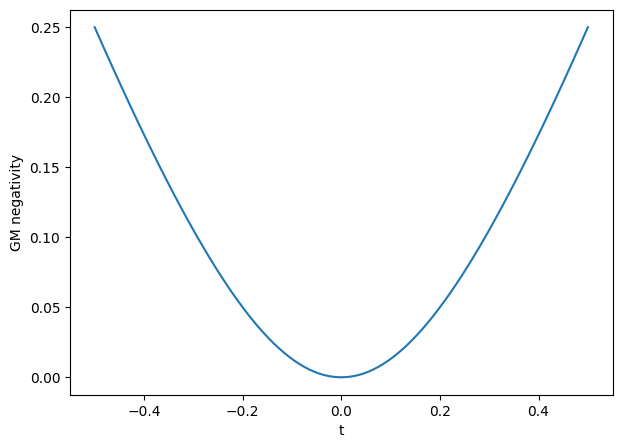

In [16]:
z = np.array([0, 0, 1])
zz = compute_tensor_product([z, z])
a, b = 0.5, 0.5

T = np.linspace(-0.5, 0.5, 100)

W_rot = []
for t in T:
     r_123 = r_123 = np.array([-t, 0, 0, 0, t, 0, 0, 0, 0, 0, t, 0, t, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
     r_rot = {(1,): a * z, (2,): a * z, (3,): a * z,
          (1, 2): b * zz, (1, 3): b * zz, (2, 3): b * zz,
          (1, 2, 3): r_123}
     
     rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
     W_rot.append(2 * compute_gm_negativity(dim, rho_rot))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(T, W_rot)

ax.set(xlabel = 't', ylabel = 'GM negativity')
plt.show()